# Contexto de cambios semanticos en iniciativas legislativas en SALUD



## Consideraciones previas
Se realizaron 50 ejecuciones independientes del enfoque Procrustes, cada una con una semilla aleatoria distinta. En cada iteración, se seleccionaron las 300 palabras con mayor cambio semántico entre los pares de períodos comparados, considerando únicamente aquellas con al menos 5 ocurrencias en alguno de los dos períodos de cinco años.

Posteriormente, se calculó la similaridad semantica promedio (medida de estabilidad del modelo) para cada palabra identificada en cada par de periodos comparados. Este valor fue estimado junto con sus respectivos intervalos de confianza del 95%, utilizando el método bootstrap.


**Umbrales cables**
* umbral_top = 0 # antes 5 se eliminan las palabras nacional (836), creacion (628), programa (488), regimen	(485), salud (483). 
* umbral_frec_menos = 2 # < antes 5 mediana de frecuencia de ocurrencia de palabra en titulos 
* umbral_frec_menos_full  = 5 # antes 9 < amedia de ocurrencia de palabra en periodo de 5 años
* topn_vecinos = 100

**Config modelo**

https://radimrehurek.com/gensim/models/word2vec.html

* tam_vector = 100 # Dimensionalidad de los vectores de palabras.
* ventana = 8 # ventana ( int , opcional ): distancia máxima entre la palabra actual y la palabra prevista dentro de una oración.
* min_frec = 2 #  Ignora todas las palabras con una frecuencia total menor que esta.
* w = 1  # utilice estos muchos subprocesos de trabajo para entrenar el modelo (=entrenamiento más rápido con máquinas de múltiples núcleos).
* s = 1 # Algoritmo de entrenamiento: 1 para skip-gram; de lo contrario, CBOW.
* e = 100 # Número de iteraciones (épocas) en el corpus. (Anteriormente: iter )
* semilla = 1 # seed ( int , opcional ): Semilla para el generador de números aleatorios. 
* iteracion = 50


 

In [1]:
# Importar librería
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import pickle
import os
import re
import random as rn
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import itertools

from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
tqdm.pandas()

from ast import literal_eval

In [2]:
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_1008211100'
pd.set_option('display.max_colwidth', None)

In [6]:
# Abrir OBJETO
with open(modelo_dir+'/top300_periodos_procrustes_df.pkl', 'rb') as file: 
    topn_periodo = pickle.load(file) ## Diccionario

In [9]:
pares_periodo = [ (2009, 2014),(2014, 2019)]
topk = 10
for par_periodo in pares_periodo:

    df = topn_periodo[par_periodo].sort_values('similaridad_semantica_mean', ascending=True)
    print("*************************")
    print(par_periodo)
    print("*************************")
    print(df.shape)
    display(df.head(topk))
    display(df.describe(include='all'))
   

*************************
(2009, 2014)
*************************
(341, 4)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals
185,"(2009, 2014)",legal,0.226934,"(0.2197858426916573, 0.2343322410331111)"
81,"(2009, 2014)",declaracion,0.240741,"(0.23174222336250705, 0.25033331633522915)"
196,"(2009, 2014)",materia,0.284821,"(0.27621661613498, 0.29415555707459196)"
118,"(2009, 2014)",empleo,0.324193,"(0.3156762836151948, 0.3334296901129995)"
324,"(2009, 2014)",tipo,0.353474,"(0.34604130294134794, 0.36105771850889146)"
174,"(2009, 2014)",ingreso,0.374986,"(0.3668404456118943, 0.38281202498794703)"
323,"(2009, 2014)",territorio,0.382965,"(0.37242475899949123, 0.39278944772354457)"
4,"(2009, 2014)",acompanante,0.385151,"(0.37897974581083105, 0.39203630333512374)"
84,"(2009, 2014)",dengue,0.393630,"(0.38782223728106535, 0.39938843959755616)"
65,"(2009, 2014)",comunitario,0.402430,"(0.39221535702842364, 0.41146943671782216)"


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals
count,341,341,341.000000,341
unique,1,341,NaN,341
top,"(2009, 2014)",legal,NaN,"(0.2197858426916573, 0.2343322410331111)"
freq,341,1,NaN,1
mean,NaN,NaN,0.628807,NaN
std,NaN,NaN,0.097842,NaN
min,NaN,NaN,0.226934,NaN
25%,NaN,NaN,0.572572,NaN
50%,NaN,NaN,0.659745,NaN
75%,NaN,NaN,0.705454,NaN


*************************
(2014, 2019)
*************************
(333, 4)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals
101,"(2014, 2019)",dispositivo,0.219099,"(0.21204005792785802, 0.2264928345362579)"
67,"(2014, 2019)",comunitario,0.281564,"(0.2716477253159932, 0.2906994000335318)"
5,"(2014, 2019)",adecuado,0.286341,"(0.2783391833057736, 0.2934617413068944)"
0,"(2014, 2019)",accesibilidad,0.298858,"(0.2878208422771088, 0.30915149192340985)"
148,"(2014, 2019)",forma,0.319486,"(0.30972586422377235, 0.32761418236121714)"
316,"(2014, 2019)",tipo,0.321460,"(0.31186169293733623, 0.3307454129021401)"
157,"(2014, 2019)",gratuidad,0.331567,"(0.32151718890583697, 0.34093582883875156)"
105,"(2014, 2019)",domiciliario,0.347000,"(0.3381872873260098, 0.3553474981386588)"
231,"(2014, 2019)",obligacion,0.373731,"(0.3658409081035276, 0.38087057662445695)"
224,"(2014, 2019)",necesario,0.374349,"(0.365838195821366, 0.3831532509455349)"


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals
count,333,333,333.000000,333
unique,1,333,NaN,333
top,"(2014, 2019)",dispositivo,NaN,"(0.21204005792785802, 0.2264928345362579)"
freq,333,1,NaN,1
mean,NaN,NaN,0.627456,NaN
std,NaN,NaN,0.102706,NaN
min,NaN,NaN,0.219099,NaN
25%,NaN,NaN,0.566346,NaN
50%,NaN,NaN,0.647331,NaN
75%,NaN,NaN,0.709830,NaN


* Cambio de 2009 a 2014
    * 341 palabras
    * similaridad_semantica_mean
        * media: 0.628807
        * mediana: 0.659745

* Cambio de 2014 a 2019
    * 333 palabras
    * similaridad_semantica_mean
        * media: 0.627456
        * mediana: 0.6473315


En general, en base la media de similaridad semantica, no se observa cambios semántico en las palabras comparadas entre pares de períodos
2009 a 2014 y 2014 a 2019.

### Distribución entre períodos


In [22]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convertir datos en DataFrame para visualización
def plot_heatmap(cambios_df, title, top = 10):
    #words, values = zip(*changed_words[:top])  # Tomamos el top 10
    #df = pd.DataFrame({"Palabra": words, "Cambio Semántico": values})
    df = cambios_df.copy()
    plt.figure(figsize=(8, 5))
    sns.heatmap(df.set_index("palabra").T, cmap="Reds", annot=True, fmt=".2f", linewidths=0.5)
    plt.title(title + " Top "+str(top))
    plt.show()

def diferencia(par):
    return par[1] - par[0]

dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos)


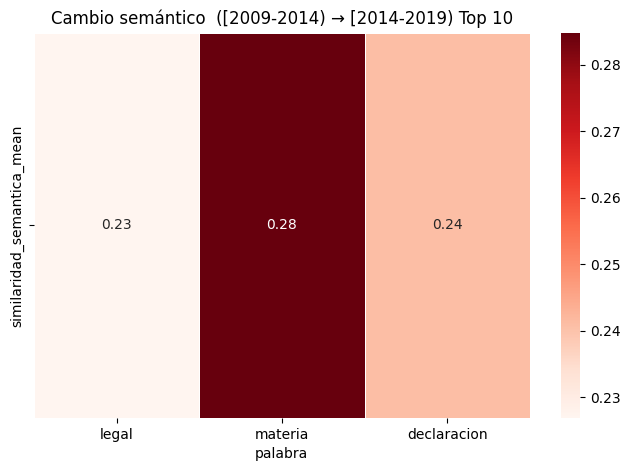

TOP 10 Palabras: ['legal' 'materia' 'declaracion']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,dispersion
185,"(2009, 2014)",legal,0.226934,"(0.2197858426916573, 0.2343322410331111)",0.014546
196,"(2009, 2014)",materia,0.284821,"(0.27621661613498, 0.29415555707459196)",0.017939
81,"(2009, 2014)",declaracion,0.240741,"(0.23174222336250705, 0.25033331633522915)",0.018591


dist ~ 0.5 (sc ~ 0.5)  Cambio moderado


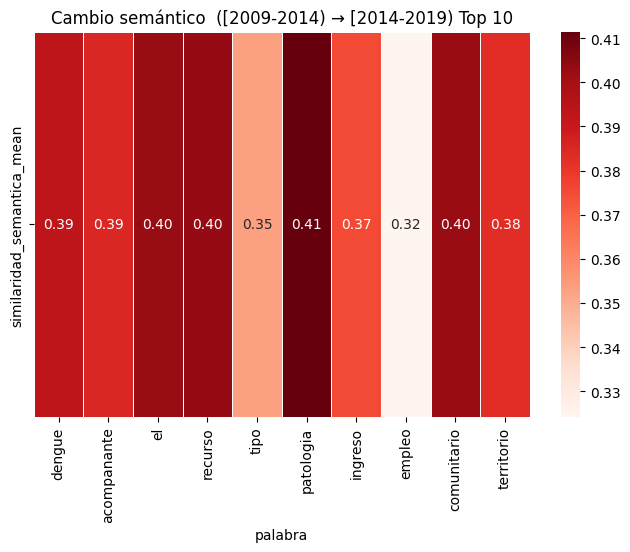

TOP 10 Palabras: ['dengue' 'acompanante' 'el' 'recurso' 'tipo' 'patologia' 'ingreso'
 'empleo' 'comunitario' 'territorio']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,dispersion
84,"(2009, 2014)",dengue,0.393630,"(0.38782223728106535, 0.39938843959755616)",0.011566
4,"(2009, 2014)",acompanante,0.385151,"(0.37897974581083105, 0.39203630333512374)",0.013057
111,"(2009, 2014)",el,0.402771,"(0.39630701946883207, 0.40986285470417655)",0.013556
281,"(2009, 2014)",recurso,0.403233,"(0.39644514292540195, 0.4105392695806274)",0.014094
324,"(2009, 2014)",tipo,0.353474,"(0.34604130294134794, 0.36105771850889146)",0.015016
237,"(2009, 2014)",patologia,0.411419,"(0.4040825419874462, 0.41921852930498793)",0.015136
174,"(2009, 2014)",ingreso,0.374986,"(0.3668404456118943, 0.38281202498794703)",0.015972
118,"(2009, 2014)",empleo,0.324193,"(0.3156762836151948, 0.3334296901129995)",0.017753
65,"(2009, 2014)",comunitario,0.402430,"(0.39221535702842364, 0.41146943671782216)",0.019254
323,"(2009, 2014)",territorio,0.382965,"(0.37242475899949123, 0.39278944772354457)",0.020365


dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos)


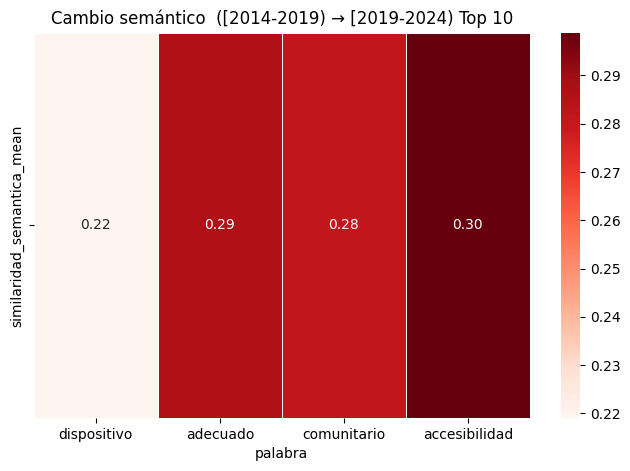

TOP 10 Palabras: ['dispositivo' 'adecuado' 'comunitario' 'accesibilidad']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,dispersion
101,"(2014, 2019)",dispositivo,0.219099,"(0.21204005792785802, 0.2264928345362579)",0.014453
5,"(2014, 2019)",adecuado,0.286341,"(0.2783391833057736, 0.2934617413068944)",0.015123
67,"(2014, 2019)",comunitario,0.281564,"(0.2716477253159932, 0.2906994000335318)",0.019052
0,"(2014, 2019)",accesibilidad,0.298858,"(0.2878208422771088, 0.30915149192340985)",0.021331


dist ~ 0.5 (sc ~ 0.5)  Cambio moderado


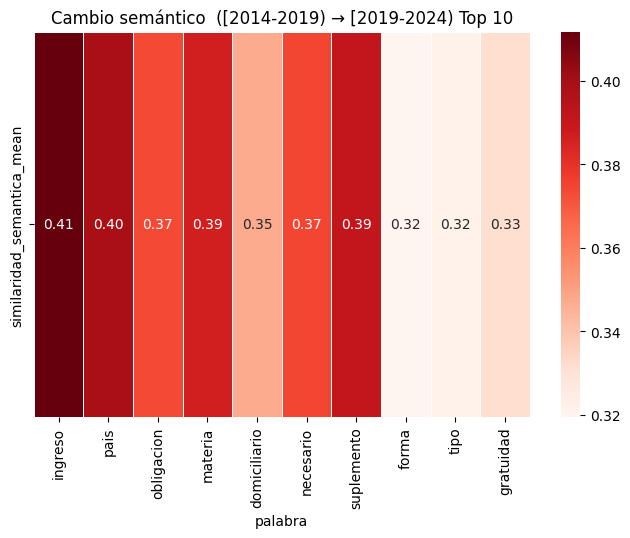

TOP 10 Palabras: ['ingreso' 'pais' 'obligacion' 'materia' 'domiciliario' 'necesario'
 'suplemento' 'forma' 'tipo' 'gratuidad']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,dispersion
177,"(2014, 2019)",ingreso,0.411782,"(0.4045175531309038, 0.41839512870415957)",0.013878
244,"(2014, 2019)",pais,0.399096,"(0.39178707465375456, 0.40648415137766064)",0.014697
231,"(2014, 2019)",obligacion,0.373731,"(0.3658409081035276, 0.38087057662445695)",0.015030
201,"(2014, 2019)",materia,0.386777,"(0.3780656807895108, 0.39469128634264417)",0.016626
105,"(2014, 2019)",domiciliario,0.347000,"(0.3381872873260098, 0.3553474981386588)",0.017160
224,"(2014, 2019)",necesario,0.374349,"(0.365838195821366, 0.3831532509455349)",0.017315
308,"(2014, 2019)",suplemento,0.391603,"(0.38201441503108124, 0.39981516180874865)",0.017801
148,"(2014, 2019)",forma,0.319486,"(0.30972586422377235, 0.32761418236121714)",0.017888
316,"(2014, 2019)",tipo,0.321460,"(0.31186169293733623, 0.3307454129021401)",0.018884
157,"(2014, 2019)",gratuidad,0.331567,"(0.32151718890583697, 0.34093582883875156)",0.019419


In [24]:
topk = 10
for par_periodo in pares_periodo:

    print("dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos)")
    periodo_df = topn_periodo[par_periodo]
    umbral_fuerte1 = 0.3
    periodo_df1 =  periodo_df[periodo_df['similaridad_semantica_mean']<=umbral_fuerte1].sort_values('similaridad_semantica_mean', ascending=True).head(topk)
    periodo_df1["dispersion"] = periodo_df1['similaridad_semantica_confidence_intervals'].apply(diferencia)
    periodo_df1 =  periodo_df1.sort_values('dispersion', ascending=True)

    # Graficar Heatmaps
    plot_heatmap(periodo_df1[['palabra','similaridad_semantica_mean']], "Cambio semántico  (["+str(par_periodo[0])+"-"+str(par_periodo[1])+") → ["+str(par_periodo[1])+"-"+str(par_periodo[1]+5)+")", top=topk)
    print("TOP 10 Palabras:", periodo_df1['palabra'].unique())
    display(periodo_df1) 
    print("dist ~ 0.5 (sc ~ 0.5)  Cambio moderado")

    umbral_fuerte2 = 0.5
    periodo_df1 =  periodo_df[(periodo_df['similaridad_semantica_mean']<=umbral_fuerte2) & (periodo_df['similaridad_semantica_mean']>umbral_fuerte1)].sort_values('similaridad_semantica_mean', ascending=True).head(topk)
    periodo_df1["dispersion"] = periodo_df1['similaridad_semantica_confidence_intervals'].apply(diferencia)
    periodo_df1 =  periodo_df1.sort_values('dispersion', ascending=True)

    # Graficar Heatmaps
    plot_heatmap(periodo_df1[['palabra','similaridad_semantica_mean']], "Cambio semántico  (["+str(par_periodo[0])+"-"+str(par_periodo[1])+") → ["+str(par_periodo[1])+"-"+str(par_periodo[1]+5)+")", top=topk)
    print("TOP 10 Palabras:", periodo_df1['palabra'].unique())
    display(periodo_df1)  


#### Cambio de 2009 a 2014
* dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos
TOP 10 Palabras: ['legal' 'declaracion' 'materia']
* dist ~ 0.5 (sc ~ 0.5)  Cambio moderado
TOP 10 Palabras: ['empleo' 'tipo' 'ingreso' 'territorio' 'acompanante' 'dengue'  'comunitario' 'el' 'recurso' 'patologia']
donde la palabra 'dengue' es la más estable en su valor similaridad_semantica_mean en las 50 corridas (0.011566) y 'territorio'
el menos (0.020365) .


#### Cambio de 2014 a 2019
* dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos
TOP 10 Palabras: ['dispositivo' 'comunitario' 'adecuado' 'accesibilidad']
* dist ~ 0.5 (sc ~ 0.5)  Cambio moderado
TOP 10 Palabras: TOP 10 Palabras: ['forma' 'tipo' 'gratuidad' 'domiciliario' 'obligacion' 'necesario'
 'materia' 'suplemento' 'pais' 'ingreso'] donde la palabra 'ingreso' es la más estable en su valor similaridad_semantica_mean en las 50 corridas (0.013878) y 'gratuidad' el menos (0.019419) .
 

#### Muerte súbita
 Palabra : Emergencia
 * 2009-2014: 0.704497
 * 2014-2019: 0.728426

##### Palabras comunes en entre todos los períodos


In [25]:
palabra_comun = set(topn_periodo[(2009, 2014)]['palabra'].unique()) & set(topn_periodo[(2014, 2019)]['palabra'].unique())
print("Cantidad de palabras en común:",len(palabra_comun))

Cantidad de palabras en común: 269


In [29]:
# Período (2009, 2014)
df = topn_periodo[(2009, 2014)]
df = df[df['palabra'].isin(palabra_comun)]
df = df[['palabra','similaridad_semantica_mean','similaridad_semantica_confidence_intervals']]
df.columns = ['palabra','ss_mean_2009_2014','ss_ci_2009_2014']
# Período (2014, 2019)
df2 = topn_periodo[(2014, 2019)]
df2 = df2[df2['palabra'].isin(palabra_comun)]
df2 = df2[['palabra','similaridad_semantica_mean','similaridad_semantica_confidence_intervals']]
df2.columns = ['palabra','ss_mean_2014_2019','ss_ci_2014_2019']
# Unión
df = df.merge(df2, how='inner', on='palabra')
df = df[['palabra', 'ss_mean_2009_2014', 'ss_mean_2014_2019', 'ss_ci_2009_2014','ss_ci_2014_2019']]
df['peso'] = (df['ss_mean_2009_2014'] + df['ss_mean_2014_2019'] )/2
df['diferencia'] = abs(df['ss_mean_2009_2014'] - df['ss_mean_2014_2019'] )

print("Top 10 de palabras comunes con fuerte cambio semántco entre Período [2009, 2014) - > [2014, 2019)  ")
print("Palabras:",df[df['peso']<=0.3].sort_values('peso').head(10)['palabra'].unique() )
display(df[df['peso']<=0.3].sort_values('peso').head(10))
print("Top 10 de palabras comunes con moderado cambio semántco entre Período [2009, 2014) - > [2014, 2019)  ")
print("Palabras:",df[(df['peso']>0.3) & (df['peso']<=0.5)].sort_values('peso').head(10)['palabra'].unique() )
display(df[(df['peso']>0.3) & (df['peso']<=0.5)].sort_values(['peso','diferencia']).head(10))

Top 10 de palabras comunes con fuerte cambio semántco entre Período [2009, 2014) - > [2014, 2019)  
Palabras: []


,palabra,ss_mean_2009_2014,ss_mean_2014_2019,ss_ci_2009_2014,ss_ci_2014_2019,peso,diferencia


Top 10 de palabras comunes con moderado cambio semántco entre Período [2009, 2014) - > [2014, 2019)  
Palabras: ['materia' 'tipo' 'comunitario' 'legal' 'ingreso' 'gratuidad'
 'domiciliario' 'necesario' 'argentina' 'obligacion']


,palabra,ss_mean_2009_2014,ss_mean_2014_2019,ss_ci_2009_2014,ss_ci_2014_2019,peso,diferencia
163,materia,0.284821,0.386777,"(0.27621661613498, 0.29415555707459196)","(0.3780656807895108, 0.39469128634264417)",0.335799,0.101956
254,tipo,0.353474,0.321460,"(0.34604130294134794, 0.36105771850889146)","(0.31186169293733623, 0.3307454129021401)",0.337467,0.032015
53,comunitario,0.402430,0.281564,"(0.39221535702842364, 0.41146943671782216)","(0.2716477253159932, 0.2906994000335318)",0.341997,0.120865
153,legal,0.226934,0.543984,"(0.2197858426916573, 0.2343322410331111)","(0.5355072224841801, 0.5524422344008969)",0.385459,0.317049
144,ingreso,0.374986,0.411782,"(0.3668404456118943, 0.38281202498794703)","(0.4045175531309038, 0.41839512870415957)",0.393384,0.036796
126,gratuidad,0.530001,0.331567,"(0.5214718258982489, 0.5361624069557221)","(0.32151718890583697, 0.34093582883875156)",0.430784,0.198435
84,domiciliario,0.524213,0.347000,"(0.5167199461129913, 0.531416305415307)","(0.3381872873260098, 0.3553474981386588)",0.435606,0.177213
180,necesario,0.514073,0.374349,"(0.5047434918073909, 0.5236054869898009)","(0.365838195821366, 0.3831532509455349)",0.444211,0.139724
23,argentina,0.449219,0.444398,"(0.44111129492781986, 0.4568838763947217)","(0.43400340817245436, 0.45397816899849425)",0.446809,0.004821
186,obligacion,0.521945,0.373731,"(0.5111122783638802, 0.5329329804811872)","(0.3658409081035276, 0.38087057662445695)",0.447838,0.148214


* Cantidad de palabras en común: 269
* Top 10 de palabras comunes con moderado cambio semántico por peso = promedio de similaridad semántica de pares de periodos. 
Palabras: ['materia' 'tipo' 'comunitario' 'legal' 'ingreso' 'gratuidad'
 'domiciliario' 'necesario' 'argentina' 'obligacion']

    * No aparece 'declaracion', pero aparecen ['legal' 'materia'] de las palabras de fuerte cambio semántico en (2009-2014). En relación a cambio semántico de las palabras identificadas con cambio moderado, solo aparecen en palabras en comunes 'tipo' e 'ingreso'. No aparecen ['empleo'  'territorio' 'acompanante' 'dengue'  'comunitario' 'el' 'recurso' 'patologia'].
    * No aparecen ['dispositivo', 'adecuado', 'accesibilidad'], pero aparece 'comunitario' de las palabras de fuerte cambio semantico en (2014-2019).En relación a cambio semántico de las palabras identificadas con cambio moderado, solo aparecen en palabras en comunes 'tipo', 'gratuidad', 'domiciliario', 'obligacion' , 'necesario' , 'ingreso' y  'materia'. No aparecen ['forma''suplemento' 'pais' ].
    * La palabra 'argentina' aparece entre las palabas de cambio moderado, cuando antes no estaban en top 10.
    * Las palabras 'legal' y "materia" pasaron de un cambio fuerte en primer par de periodos a moderado en segundo par de periodos. Mientras que  comunitario paso de cambio moderado en primer par de periodos a fuerte en segundo par de periodos



### Análisis de temporalidad

¿Cuándo se usan más estas palabras en los títulos?


In [30]:
# Abrir
with open(os.getenv("DIR_DATOS_PROCESADOS") + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    basetexto_df = pickle.load(file)

basetexto_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Proyecto.ID,35179,35179,HCDN246858,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título,35179,33168,JUICIO POR JURADOS. CREACION.,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título procesado,35179,29558,contrato de trabajo ley numero modificacion del articulo numero sobre licencias especiales,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título normalizado,35179,28761,licencia especial,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cant_token,35179.0,NaN,NaN,NaN,21.123682,10.69187,2.0,14.0,19.0,27.0,125.0
Cant_token_normalizado,35179.0,NaN,NaN,NaN,9.76341,5.051387,0.0,6.0,9.0,12.0,57.0
Proyecto_girado_a_comisiones_SALUD,35179.0,NaN,NaN,NaN,0.12786,0.333939,0.0,0.0,0.0,0.0,1.0
Proyecto_SALUD,35179.0,NaN,NaN,NaN,0.085761,0.280015,0.0,0.0,0.0,0.0,1.0
Resultado,35179,6,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,34268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Max_Orden,35179.0,NaN,NaN,NaN,2.253504,0.822105,1.0,2.0,2.0,3.0,8.0


In [31]:
# Seleccionando IL de Salud
basetexto_df = basetexto_df[basetexto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",basetexto_df.shape)
basetexto_df = basetexto_df[~basetexto_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",basetexto_df.shape)

Conj. de datos de proyecto_SALUD con Nan en Período: (3017, 14)
Conj. de datos de proyecto_SALUD sin Nan en Período: (2848, 14)


In [33]:
basetexto_df.head(1)

,Proyecto.ID,Título,Título procesado,Título normalizado,Cant_token,Cant_token_normalizado,Proyecto_girado_a_comisiones_SALUD,Proyecto_SALUD,Resultado,Max_Orden,Tiene_antecedente_por_titulo_proy,Periodo,Año,Tokens
2061,HCDN272685,INCLUYASE EN EL CALENDARIO NACIONAL DE VACUNACION CON CARACTER OBLIGATORIO Y GRATUITO LA VACUNA CONTRA EL VIRUS DEL DENGUE. MODIFICACION DE LA LEY 27491.,incluyase en el calendario nacional de vacunacion con caracter obligatorio y gratuito la vacuna contra el virus del dengue modificacion de la ley numero,incluyar calendario nacional vacunacion caracter obligatorio gratuito vacuna virus dengue,24,10,1.0,1.0,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,3,False,141.0,2024,"[incluyar, calendario, nacional, vacunacion, caracter, obligatorio, gratuito, vacuna, virus, dengue]"


In [34]:
basetexto_df.columns

Index(['Proyecto.ID', 'Título', 'Título procesado', 'Título normalizado',
       'Cant_token', 'Cant_token_normalizado',
       'Proyecto_girado_a_comisiones_SALUD', 'Proyecto_SALUD', 'Resultado',
       'Max_Orden', 'Tiene_antecedente_por_titulo_proy', 'Periodo', 'Año',
       'Tokens'],
      dtype='object')

In [60]:
## Para analizar
palabras_comunes =  ['materia', 'tipo' ,'comunitario', 'legal', 'ingreso', 'gratuidad',
 'domiciliario' ,'necesario' ,'argentina' ,'obligacion']
palabras_emergentes = ['declaracion','empleo' , 'territorio' ,'acompanante', 'dengue' , 'comunitario' ,'recurso', 'patologia','dispositivo', 'adecuado', 'accesibilidad','forma','suplemento', 'pais']

In [65]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm

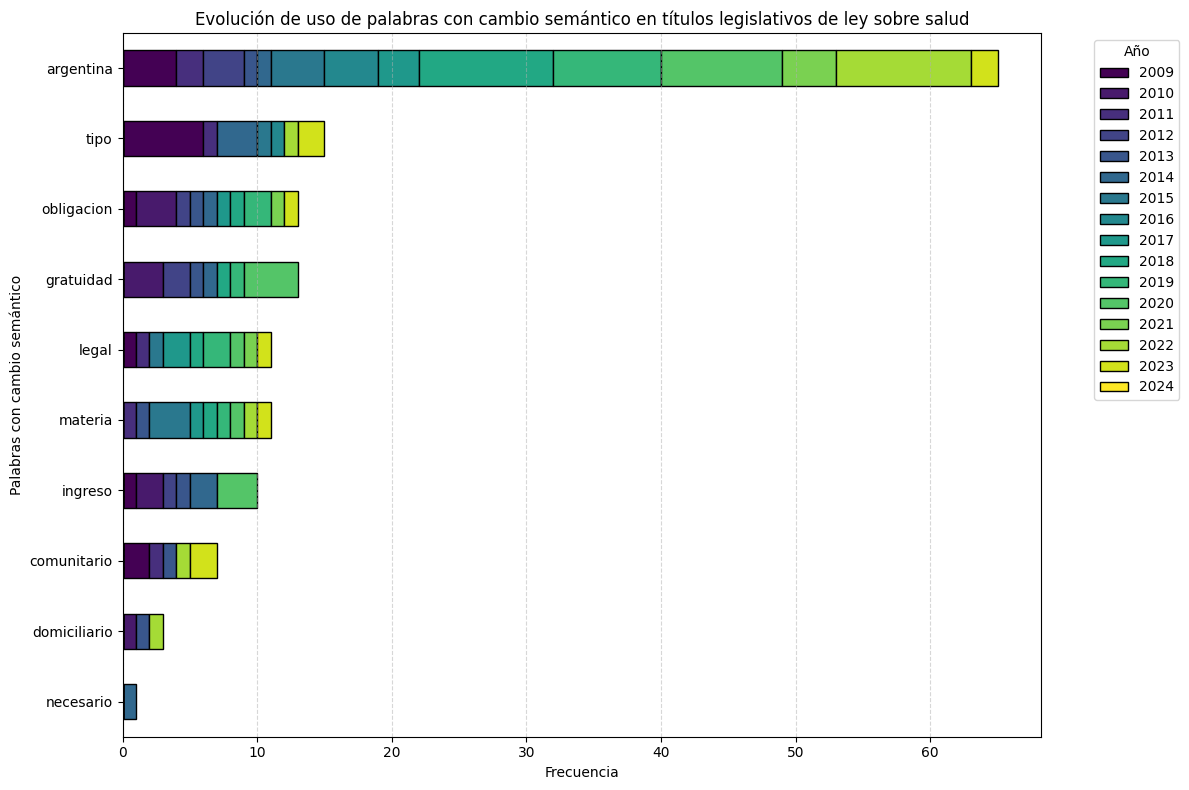

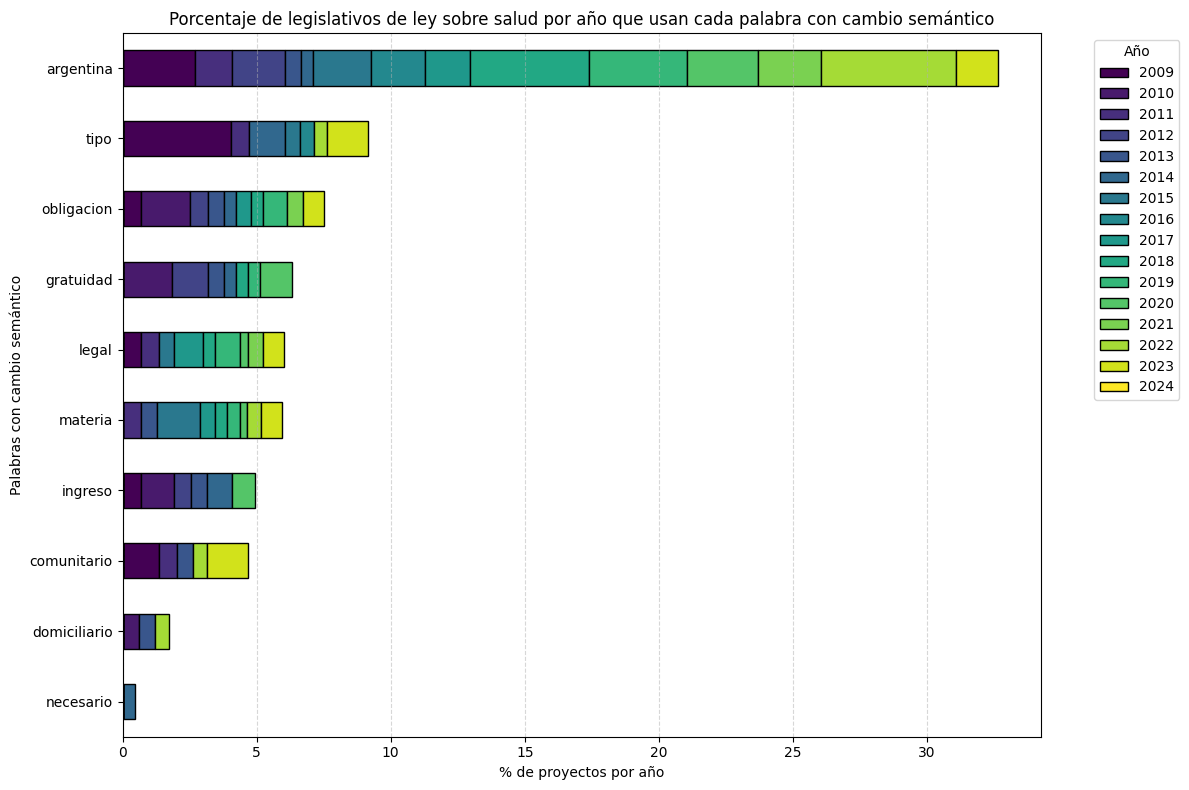

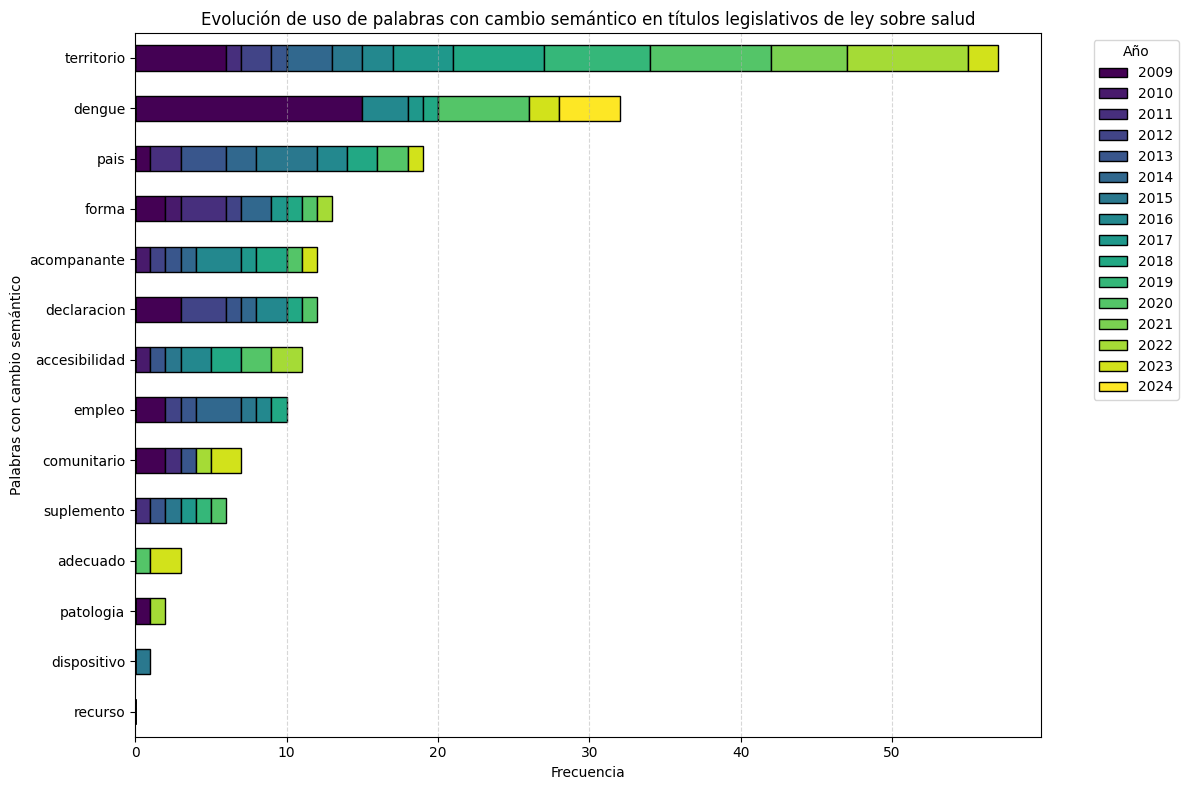

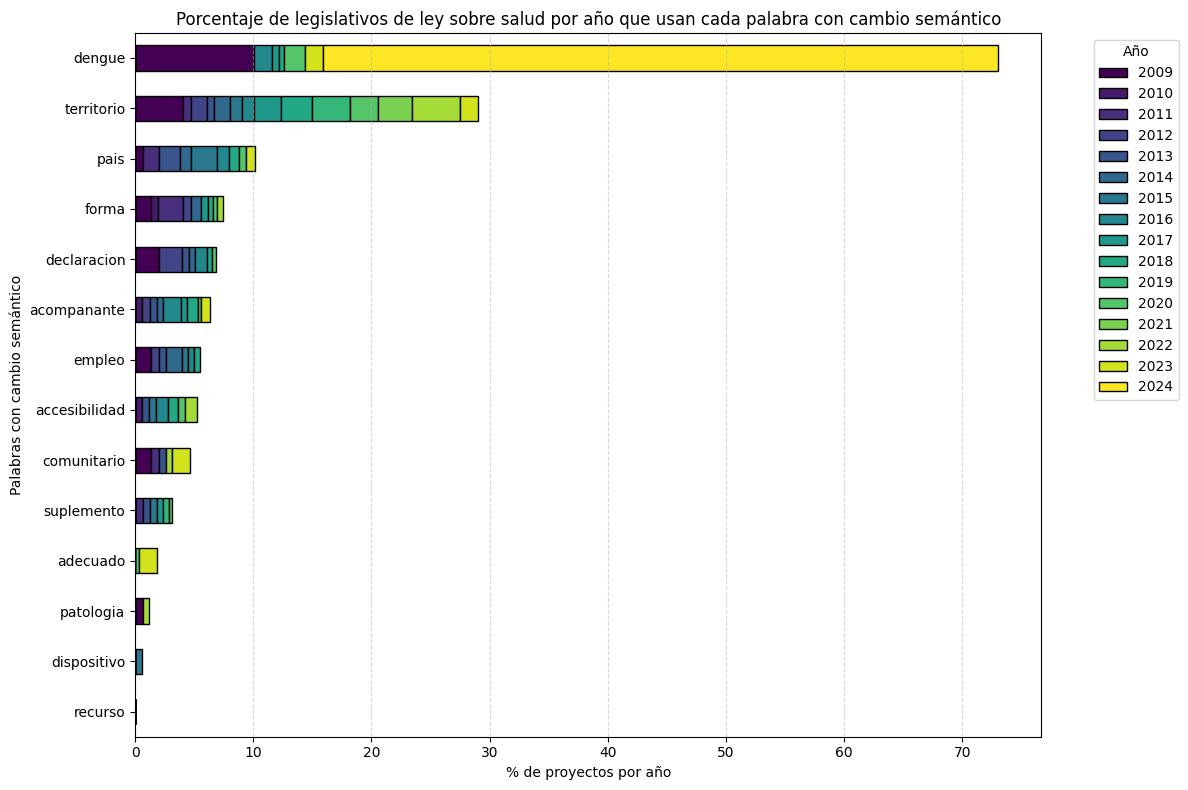

In [67]:

for palabras_objetivo in [palabras_comunes,palabras_emergentes]:
    
    # Inicializar un diccionario de conteo por año
    frecuencia_por_anio = {palabra: {} for palabra in palabras_objetivo}
    
    # Iterar por año
    for año, grupo in basetexto_df.groupby('Año'):
        textos = " ".join(grupo['Título procesado'].tolist())
        conteo = Counter(textos.split())
    
        for palabra in palabras_objetivo:
            frecuencia_por_anio[palabra][año] = conteo.get(palabra, 0)
    
    # Convertir a DataFrame
    frecuencia_df = pd.DataFrame(frecuencia_por_anio).fillna(0).astype(int).sort_index()
    frecuencia_df = frecuencia_df.T
    frecuencia_df['total'] = frecuencia_df.sum(axis=1)
    frecuencia_df = frecuencia_df.sort_values('total', ascending=True).drop(columns='total')
    
    frecuencia_df.plot(kind='barh',
                       stacked=True,
                       figsize=(12, 8),
                       colormap='viridis',  
                       edgecolor='black')
    
    plt.title('Evolución de uso de palabras con cambio semántico en títulos legislativos de ley sobre salud')
    plt.xlabel('Frecuencia')
    plt.ylabel('Palabras con cambio semántico')
    plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()
    
    
    # Cantidad de proyectos por año (para normalizar)
    total_proyectos_por_anio = basetexto_df.groupby('Año').size()
    # frecuencia_df tiene palabras como índice y años como columnas (frecuencia absoluta)
    frecuencia_relativa_df = frecuencia_df.div(total_proyectos_por_anio, axis=1) * 100  # multiplicamos por 100 para %
    # Ordenar por promedio total para ordenar mejor las barras
    frecuencia_relativa_df['Promedio'] = frecuencia_relativa_df.mean(axis=1)
    frecuencia_relativa_df = frecuencia_relativa_df.sort_values('Promedio', ascending=True).drop(columns='Promedio')
    frecuencia_relativa_df.plot(kind='barh',
                                stacked=True,
                                figsize=(12, 8),
                                colormap='viridis',
                                edgecolor='black')
    
    plt.title('Porcentaje de legislativos de ley sobre salud por año que usan cada palabra con cambio semántico')
    plt.xlabel('% de proyectos por año')
    plt.ylabel('Palabras con cambio semántico')
    plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()






### Análisis de actividad legislativa

In [71]:
basetexto_df.columns

Index(['Proyecto.ID', 'Título', 'Título procesado', 'Título normalizado',
       'Cant_token', 'Cant_token_normalizado',
       'Proyecto_girado_a_comisiones_SALUD', 'Proyecto_SALUD', 'Resultado',
       'Max_Orden', 'Tiene_antecedente_por_titulo_proy', 'Periodo', 'Año',
       'Tokens', 'contiene_materia', 'contiene_tipo', 'contiene_comunitario',
       'contiene_legal', 'contiene_ingreso', 'contiene_gratuidad',
       'contiene_domiciliario', 'contiene_necesario', 'contiene_argentina',
       'contiene_obligacion'],
      dtype='object')

In [75]:
# Convertimos a minúscula y verificamos si la palabra aparece en el título
for palabras_clave in [palabras_comunes,  palabras_emergentes]:
     
    for palabra in palabras_clave:
        basetexto_df[f'contiene_{palabra}'] = basetexto_df['Título normalizado'].str.contains(rf'\b{palabra}\b', case=False)
    
    for palabra in palabras_clave:
        grupo = basetexto_df[basetexto_df[f'contiene_{palabra}']]
        print(f'\nAnálisis para la palabra "{palabra}":')
        print('Cantidad de proyectos:', len(grupo))
        print('Promedio de Max orden:', grupo['Max_Orden'].mean())
        print('Moda Resultado:', grupo['Resultado'].mode()[0])


Análisis para la palabra "materia":
Cantidad de proyectos: 12
Promedio de Max orden: 2.9166666666666665
Moda Resultado: NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN

Análisis para la palabra "tipo":
Cantidad de proyectos: 17
Promedio de Max orden: 2.176470588235294
Moda Resultado: NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN

Análisis para la palabra "comunitario":
Cantidad de proyectos: 16
Promedio de Max orden: 2.375
Moda Resultado: NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN

Análisis para la palabra "legal":
Cantidad de proyectos: 14
Promedio de Max orden: 2.642857142857143
Moda Resultado: NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN

Análisis para la palabra "ingreso":
Cantidad de proyectos: 15
Promedio de Max orden: 2.466666666666667
Moda Resultado: NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN

Análisis para la palabra "gratuidad":
Cantidad de proyectos: 12
Promedio de Max orden: 2.75
Moda Resultado: NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN

Análisis para la palabra "domiciliario":
Cantidad 

### Análisis por comisiones dominantes

In [77]:
# Leemos objeto para mapeear con giro de comisiones
with open(os.getenv("DIR_DATOS_PROCESADOS") +'BD_girocom_df_20250118.pkl', 'rb') as file:
    BD_girocom_df = pickle.load(file)

In [78]:
# BD giro comisión
BD_girocom_df.head(4)

,comision_nombre,archivo_fuente,comision_nombre_normalizada
0,SOBRE TABLAS,giro comision,sobre tablas
1,OBRAS PUBLICAS,giro comision,obras publicas
2,PRESUPUESTO Y HACIENDA,giro comision,presupuesto y hacienda
3,TURISMO,giro comision,turismo


In [80]:
FUENTE_DIR = os.getenv("DIR_FUENTE_DATOS") # Acceder a las variables de entorno
girocom_df = pd.read_csv(FUENTE_DIR+'diputados/giroacomisiones2.0.csv')
print('Tamaño de dataset de Giro a comisiones:',girocom_df.shape)
display(girocom_df.head(2))
display(girocom_df.describe(include='all').T)

Tamaño de dataset de Giro a comisiones: (404653, 3)


,Proyecto.ID,Comisión,Orden
0,HCDN000000,SOBRE TABLAS,1
1,HCDN001090,OBRAS PUBLICAS,1


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Proyecto.ID,404653,267339,HCDN061700,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Comisión,404653,196,PRESUPUESTO Y HACIENDA,47738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Orden,404653.0,NaN,NaN,NaN,1.481912,0.802812,1.0,1.0,1.0,2.0,13.0


In [82]:
# Leemos BD de comisiones normalizadas
with open(os.getenv("DIR_DATOS_PROCESADOS") +'BD_normalizada_df_20250118.pkl', 'rb') as file:
    BD_normalizada_df = pickle.load(file)

In [83]:
BD_normalizada_df.head(3)

,comision_nombre_normalizada,archivo_fuente,comision_nombre_normalizada_Levenshtein
0,a la presidencia,giro comision,a la presidencia
1,a sus antecedentes,giro comision,a sus antecedentes
2,accion social y salud publica,"giro comision, dictamen, comision",accion social y salud publica


In [84]:
# BD_girocom_df para integrar con proyecto
llave = 'comision_nombre_normalizada'
temp_df = pd.merge(BD_girocom_df, BD_normalizada_df, how ='inner', left_on = llave, right_on = llave)[['comision_nombre','comision_nombre_normalizada_Levenshtein']]
display(temp_df.head(4))
display(temp_df.shape)

,comision_nombre,comision_nombre_normalizada_Levenshtein
0,SOBRE TABLAS,sobre tablas
1,OBRAS PUBLICAS,obras publicas
2,PRESUPUESTO Y HACIENDA,presupuesto y hacienda
3,TURISMO,turismo


(196, 2)

In [85]:
del BD_normalizada_df
del BD_girocom_df

In [86]:
# Mapeo proyecto - comisiones
girocom_df[['Proyecto.ID','Comisión']].drop_duplicates().sort_values('Proyecto.ID')

,Proyecto.ID,Comisión
0,HCDN000000,SOBRE TABLAS
1,HCDN001090,OBRAS PUBLICAS
2,HCDN001090,PRESUPUESTO Y HACIENDA
3,HCDN001091,TURISMO
4,HCDN001092,ASUNTOS CONSTITUCIONALES
...,...,...
404647,HCDN280535,"FAMILIAS, NIÑEZ Y JUVENTUDES"
404649,HCDN280536,EDUCACION
404651,HCDN280537,LIBERTAD DE EXPRESION
404650,HCDN280537,ASUNTOS CONSTITUCIONALES


In [87]:
temp2_df = pd.merge(girocom_df[['Proyecto.ID','Comisión']].drop_duplicates(),temp_df, how ='inner', left_on = 'Comisión', right_on = 'comision_nombre')[['Proyecto.ID','comision_nombre_normalizada_Levenshtein']].drop_duplicates()
temp2_df.head(3)

,Proyecto.ID,comision_nombre_normalizada_Levenshtein
0,HCDN000000,sobre tablas
1,HCDN001090,obras publicas
2,HCDN001090,presupuesto y hacienda


In [89]:
basetexto_com_df = pd.merge(basetexto_df,temp2_df, how ='inner', left_on = 'Proyecto.ID', right_on = 'Proyecto.ID')
basetexto_com_df.shape

(6936, 38)

In [94]:
# Comisiones 
basetexto_com_df['comision_nombre_normalizada_Levenshtein'].value_counts( normalize=True )

comision_nombre_normalizada_Levenshtein
accion social y salud publica                                             0.410611
presupuesto y hacienda                                                    0.271338
legislacion general                                                       0.054066
familia mujer ninez y adolescencia                                        0.031142
educacion                                                                 0.023789
comercio                                                                  0.022059
legislacion del trabajo                                                   0.020473
industria                                                                 0.020185
discapacidad                                                              0.017589
prevencion de adicciones y control del narcotrafico                       0.015138
comunicaciones e informatica                                              0.013985
familias ninez y juventudes                    

In [96]:
# Convertimos a minúscula y verificamos si la palabra aparece en el título
for palabras_clave in [palabras_comunes,  palabras_emergentes]:
       
    for palabra in palabras_clave:
        grupo = basetexto_com_df[basetexto_com_df[f'contiene_{palabra}']]
        com_df = grupo['comision_nombre_normalizada_Levenshtein'].value_counts( normalize=True)
        print(f'\nAnálisis para la palabra "{palabra}":')
        print('Cantidad de comisiones:', len(com_df))
        print('Detalle de comisiones:', com_df)
        


Análisis para la palabra "materia":
Cantidad de comisiones: 12
Detalle de comisiones: comision_nombre_normalizada_Levenshtein
accion social y salud publica                          0.352941
presupuesto y hacienda                                 0.235294
prevencion de adicciones y control del narcotrafico    0.088235
educacion                                              0.058824
familia mujer ninez y adolescencia                     0.058824
comunicaciones e informatica                           0.029412
legislacion del trabajo                                0.029412
justicia                                               0.029412
poblacion y desarrollo humano                          0.029412
peticiones poderes y reglamento                        0.029412
salud y deporte                                        0.029412
deportes                                               0.029412
Name: proportion, dtype: float64

Análisis para la palabra "tipo":
Cantidad de comisiones: 10
Detalle de 